# Import Bibliotek

In [370]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Wczytanie Danych

In [371]:
ocena_subskrypcji = pd.read_csv('../data/raw/ocena_subskrypcji.csv', sep = ';')
ocena_subskrypcji.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# EDA

In [372]:
ocena_subskrypcji.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [373]:
ocena_subskrypcji.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

In [374]:
ocena_subskrypcji.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

**Zbiór danych jest kompletny pod względem technicznym (brak wartości typu Null). Część rekordów w zmiennych kategorycznych (np. wykształcenie) zawiera wartość 'unknown' oznacza to brak odpowiedzi respondenta. W danych występuje duże zróżnicowanie finansowe ankietowanych, a bazę stanowią w znacznej części nowe osoby, które wcześniej nie były ankietowane. Średnio do jedne osoby dzwoniono od 2 do 3 razy, jednak zdarzały się przypadki większej ilości połączceń. Średnia długość połączenia wynosiła 4 minuty.**

# WYKRESY ŚREDNIA

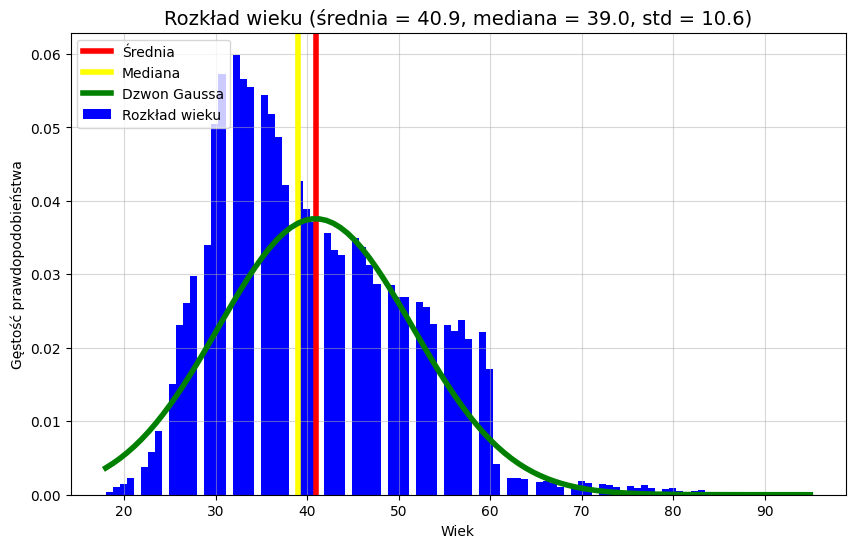

In [375]:
sredni_wiek = ocena_subskrypcji.age.mean()
sigma = ocena_subskrypcji.age.std()
median = ocena_subskrypcji.age.median()
x = np.linspace(ocena_subskrypcji.age.min(), ocena_subskrypcji.age.max(), 100)
p = norm.pdf(x, sredni_wiek, sigma)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(ocena_subskrypcji.age, density = True, bins=100, color = 'blue')
ax.grid(True, which='both', alpha=0.5 )
ax.axvline(sredni_wiek, color='red', linewidth=4)
ax.axvline(median, color='yellow', linewidth=4)
ax.plot(x, p, color='green', linewidth=4)
ax.set_title(f'Rozkład wieku (średnia = {sredni_wiek:.1f}, mediana = {median:.1f}, std = {sigma:.1f})', fontsize=14)
ax.set_xlabel('Wiek')
ax.set_ylabel('Gęstość prawdopodobieństwa')
ax.legend(labels=['Średnia','Mediana','Dzwon Gaussa', "Rozkład wieku"], loc='upper left')

plt.show()

**Rozkład średniego wieku ankietowanych jest prawoskośny. Większość ankietowanych znajduję się w przedziale wieku od 30 do 50 lat. Średni wiek ankietowanych wynosi około 41 lat, a mediana 39 lat. Oznacza to, że nieliczna grupa starszych ankietowanych lekko zawyża średnią.**

# WYKRESY ZATRUDNIENIA

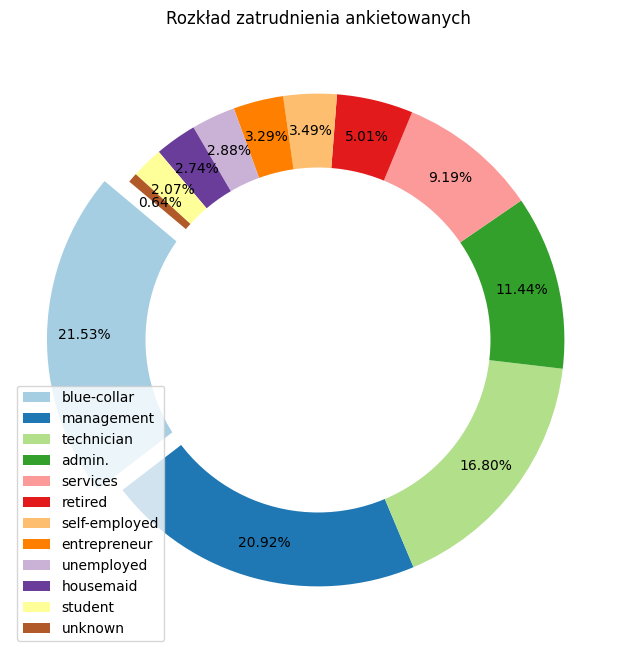

In [376]:
zawod = ocena_subskrypcji.value_counts(ocena_subskrypcji.job)
explode = [0.1 if i == 0 else 0 for i in range(len(zawod))]

fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(zawod, autopct='%1.2f%%', radius=1, startangle=140, explode=explode, colors=plt.cm.Paired.colors, pctdistance=0.85)
circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(circle)
ax.set_title("Rozkład zatrudnienia ankietowanych")
ax.legend(zawod.index)

plt.show()

**Pracownicy fizyczni (blue-collar) oraz kadra zarządzająca (management) stanowią dominującą grupę ankietowanych.**

# WYKRESY DECYZJI

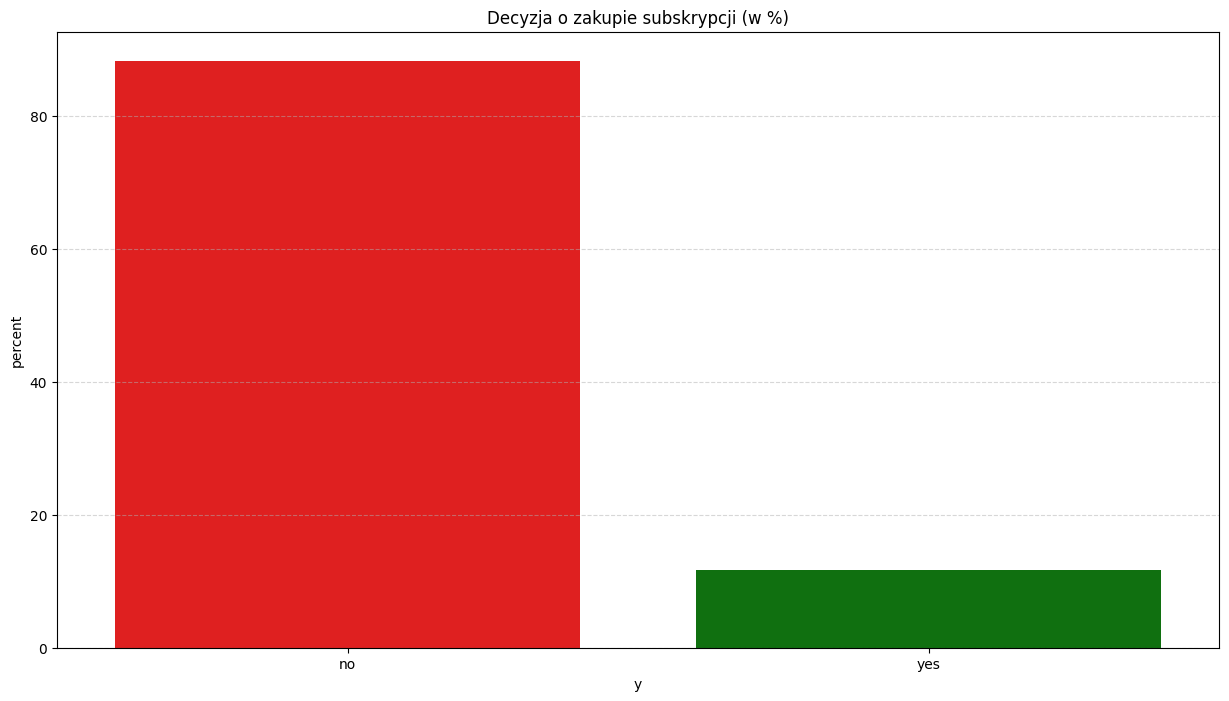

In [377]:
decyzja = ocena_subskrypcji.value_counts(ocena_subskrypcji.y)
kolor={"yes":"green","no":"red"}

fig , ax = plt.subplots(figsize=(15, 8))
sns.countplot(data=ocena_subskrypcji, x='y', hue='y', palette=kolor, stat="percent", legend=False)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.set_title("Decyzja o zakupie subskrypcji (w %)")
plt.show()


In [378]:
print(f"Wskaźnik konwersji {(decyzja['yes']/(decyzja['no']+decyzja['yes']))*100:.2f} %")

Wskaźnik konwersji 11.70 %


**Wskaźnik konwersji, czyli odsetek zgód na subskrypcję wśród ankietowanych, wyniósł 11,70%. Oznacza to, że pozytywną odpowiedź wyrażała średnio co dziewiąta lub dziesiąta ankietowana osoba.**

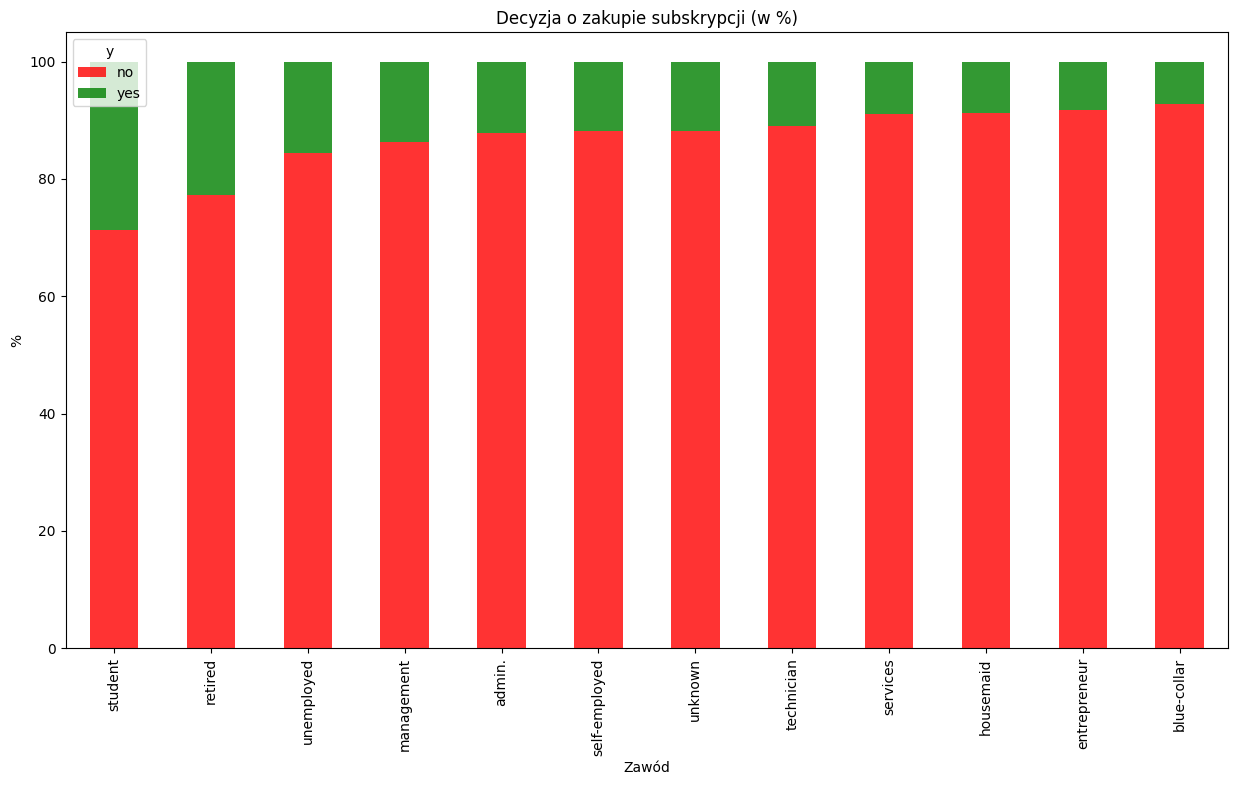

In [379]:
kopia_tab = ocena_subskrypcji.copy()

procenty_zawod = pd.crosstab(kopia_tab['job'], kopia_tab['y'], normalize='index') * 100
procenty_zawod = procenty_zawod.sort_values(by='yes', ascending=False)
fig , ax = plt.subplots(figsize=(15, 8))
procenty_zawod.plot(kind='bar', stacked=True, color=['red', 'green'], alpha=0.8, ax=ax)
ax.set_title("Decyzja o zakupie subskrypcji (w %)")
ax.set_xlabel("Zawód")
ax.set_ylabel("%")

plt.show()

**Grupy o najwyższym współczynniku konwersji to studenci oraz emeryci (przekraczający 20% zgód). Na trzecim miejscu znajdują się osoby bezrobotne. Najniższą skłonność do zakupu subskrypcji wykazują pracownicy fizyczni (blue-collar) stanowiący najliczniejszą ankietowaną grupę.**

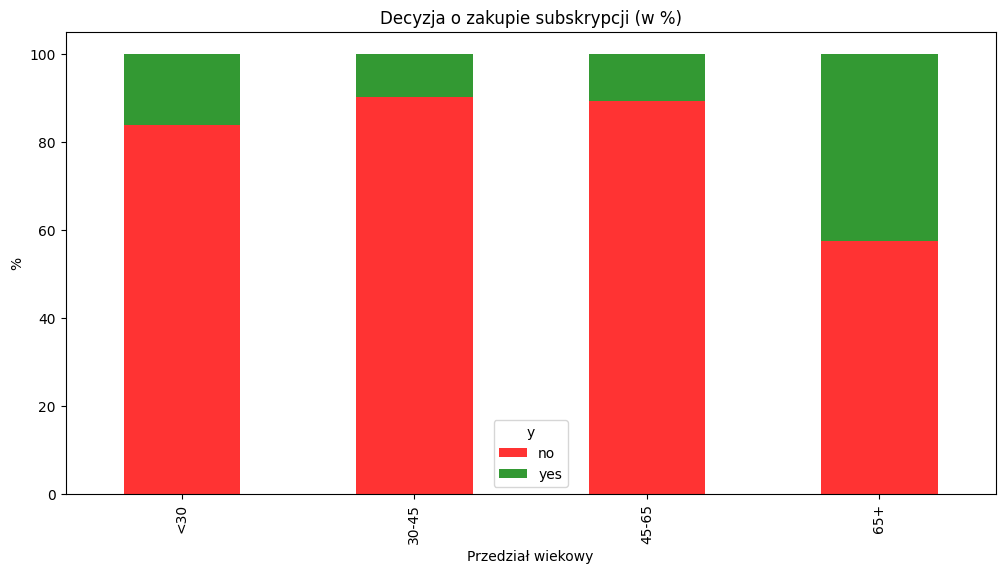

In [380]:
granice = [0 , 30, 45, 65, 100]
etykiety = ['<30', '30-45', '45-65', '65+']
kopia_tab['age_group'] = pd.cut(kopia_tab['age'], bins=granice, labels=etykiety)
procenty_wiek = pd.crosstab(kopia_tab['age_group'], kopia_tab['y'], normalize='index') * 100
procenty_wiek = procenty_wiek.sort_values(by='age_group', ascending=True)
fig, ax = plt.subplots(figsize=(15, 8))
procenty_wiek.plot(kind='bar', stacked=True, figsize=(12, 6), color=['red', 'green'], alpha=0.8,ax=ax)
ax.set_title("Decyzja o zakupie subskrypcji (w %)")
ax.set_xlabel("Przedział wiekowy")
ax.set_ylabel("%")
plt.show()

**Wraz ze wzrostem wieku ankietowanych wzrasta ich współczynnik konwersji. Praktycznie co 2 osoba w wieku powyżej 65 lat decyduje się na ofertę. Drugą grupą o podwyższonym współczynniku konwersji są osoby poniżej 30 roku życia, osoby w przedziale wiekowym od 30-45 lat oraz 45-65 wyróżniają się najniższym współczynnikiem konwersji co jest istotne ponieważ stanowią najliczniejsze grupy ankietowanych**

# KORELACJA

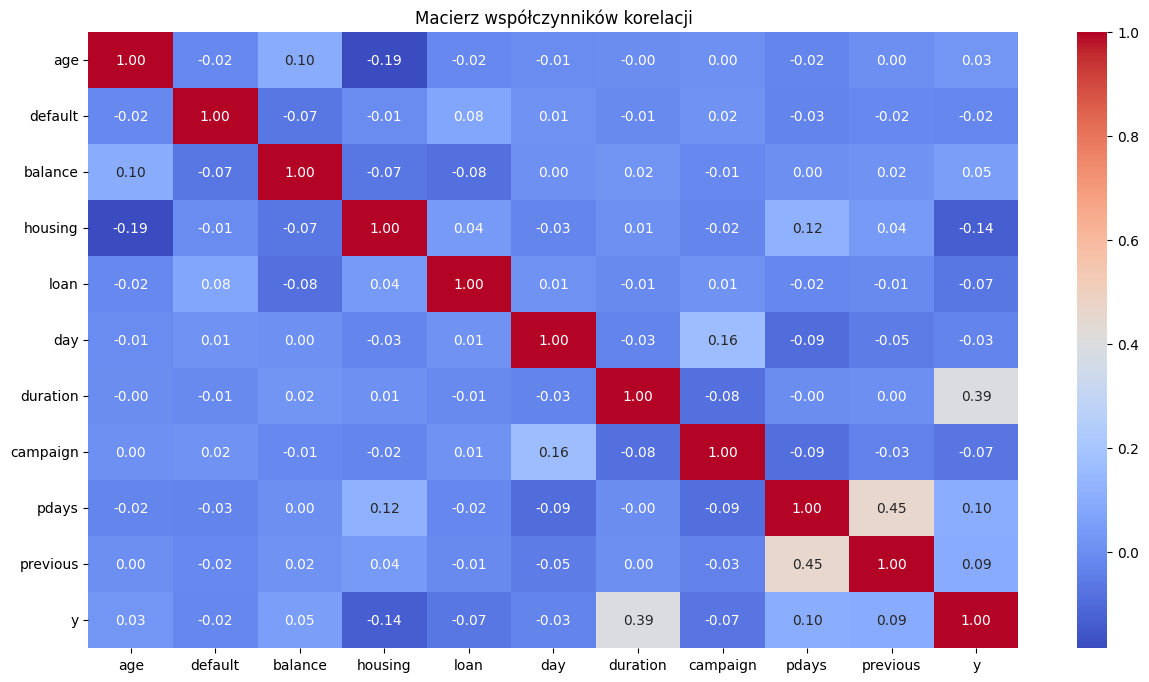

In [382]:
df_corr = ocena_subskrypcji.copy()
bin_cols=['default','housing','loan','y']
for col in bin_cols:
    df_corr[col]=df_corr[col].map({'yes':1, 'no':0})

matrix = df_corr.select_dtypes(include=['number']).corr()

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(matrix, annot=True, fmt=".2f", ax=ax, cmap='coolwarm')
ax.set_title("Macierz współczynników korelacji")
plt.show()

* **Czas trawania rozmowy (duration) ma największy wpływ na to czy ankietowany zdecyduje się na subskrypcje. (zmienna nie jest dostępna przed wykonaniem połączenia, wyciek danych w przypadku modelowania)**
* **Posiadanie przez ankietowanego kredytu hipotecznego (housing) zmniejsza szanse na decyzję o subskrypcji.**
* **Dane nie wykazują silnych wzajemynch korelacji.**